# Praktikum IF3270 Pembelajaran Mesin
## Customer Segmentation Classification — Loan Status Prediction

**Nama Anggota:**
- 13523099 — Daniel Pedrosa Wu
- 13523103 — Steven Owen Liauw

**Kelas:** K02

---

## 1. Import Libraries

In [1]:
!pip install xgboost==3.2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 34.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install lightgbm==4.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 59.7 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold,RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler, MaxAbsScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.base import clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.utils.class_weight import compute_sample_weight

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load Data

In [4]:
TARGET      = "loan_status"
ID_COL      = "person_id"
TRAIN_PATH  = "/work/train.csv"
TEST_PATH   = "/work/test.csv"
SCORING     = "f1_macro"
F1_AVERAGE  = "macro"

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

df_train.head()

,person_id,person_age,person_gender,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,6049,24.0,male,58914.0,2,OWN,4400.0,5.99,0.07,4.0,656,Yes,0
1,3347,23.0,female,45873.0,2,RENT,11000.0,11.01,0.24,2.0,634,Yes,0
2,17999,29.0,female,240947.0,7,MORTGAGE,10000.0,12.69,0.04,9.0,638,Yes,0
3,24989,30.0,female,96316.0,10,MORTGAGE,6000.0,13.49,0.06,8.0,682,No,0
4,23232,29.0,male,73033.0,7,MORTGAGE,8000.0,10.51,0.11,8.0,644,Yes,0


---
## 3. Exploratory Data Analysis
### Questions about dataset
1. Apakah dataset mengandung null values ?
2. Apakah dataset memiliki skewness pada distribusi data ?
3. Apakah dataset memiliki outliers ?

### 3.1 Data Integrity

In [5]:
print(f"Train shape: {df_train.shape}")
print(f"Test  shape: {df_test.shape}")
print(f"\nDuplicate rows (train): {df_train.duplicated().sum()}")
print(f"Duplicate rows (test):  {df_test.duplicated().sum()}")

df_train.info()

Train shape: (36000, 13)
Test  shape: (9000, 12)

Duplicate rows (train): 0
Duplicate rows (test):  0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_id                       36000 non-null  int64  
 1   person_age                      36000 non-null  float64
 2   person_gender                   36000 non-null  object 
 3   person_income                   36000 non-null  float64
 4   person_emp_exp                  36000 non-null  int64  
 5   person_home_ownership           36000 non-null  object 
 6   loan_amnt                       36000 non-null  float64
 7   loan_int_rate                   36000 non-null  float64
 8   loan_percent_income             36000 non-null  float64
 9   cb_person_cred_hist_length      36000 non-null  float64
 10  credit_score                    36000 non-null  int6

In [6]:
missing = df_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if not missing.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    missing.plot.barh(ax=ax, color="salmon")
    ax.set_title("Missing Values per Feature")
    ax.set_xlabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values.")

No missing values.


1. Tidak ada Missing Values pada dataset

### 3.2 Feature Separation (Dynamic)

In [7]:
feature_cols = [c for c in df_train.columns if c not in [ID_COL, TARGET]]

num_cols = df_train[feature_cols].select_dtypes(include="number").columns.tolist()
cat_cols = df_train[feature_cols].select_dtypes(exclude="number").columns.tolist()

print(f"Numerical  ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")

Numerical  (8): ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
Categorical (3): ['person_gender', 'person_home_ownership', 'previous_loan_defaults_on_file']


### 3.3 Univariate Analysis

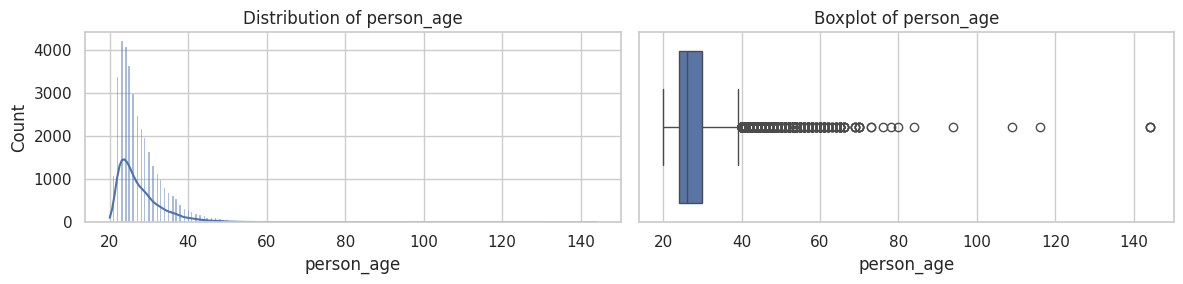

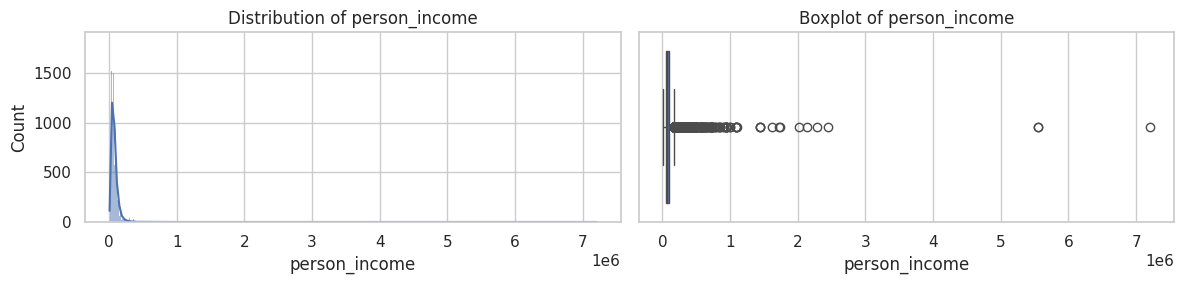

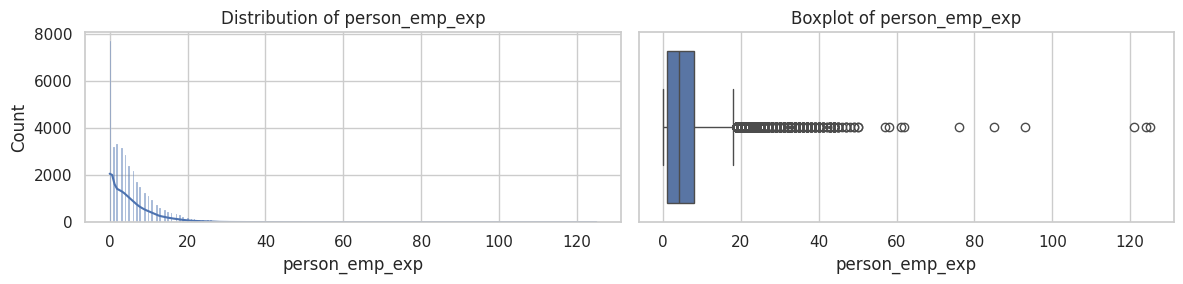

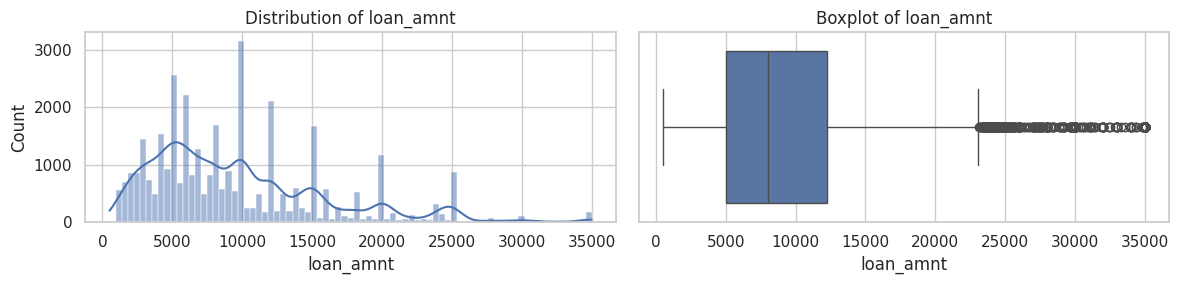

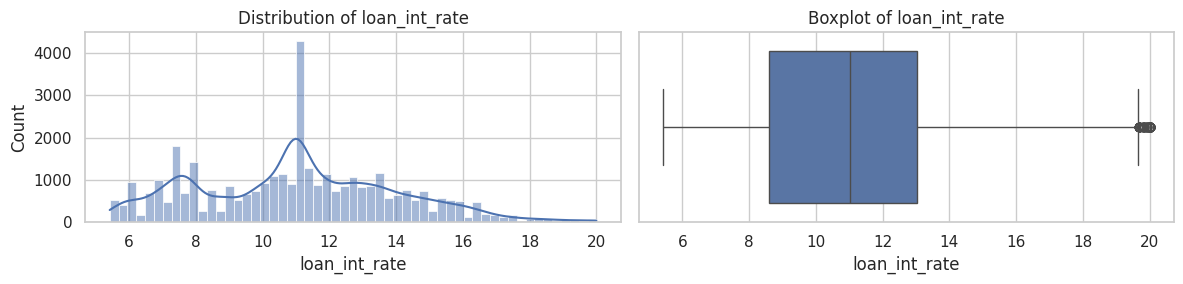

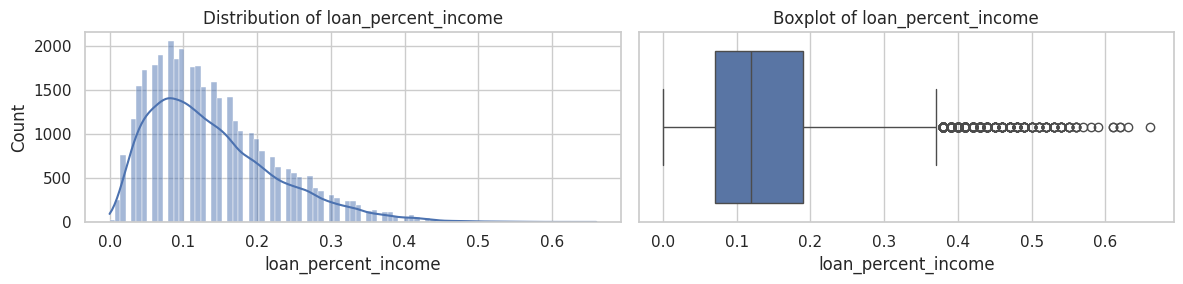

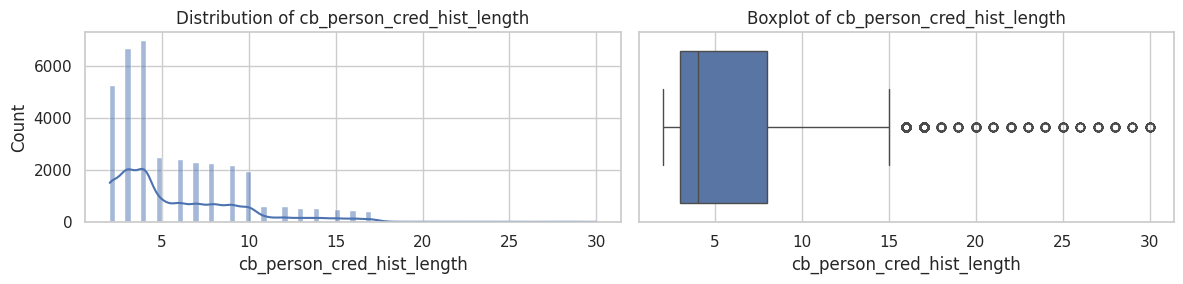

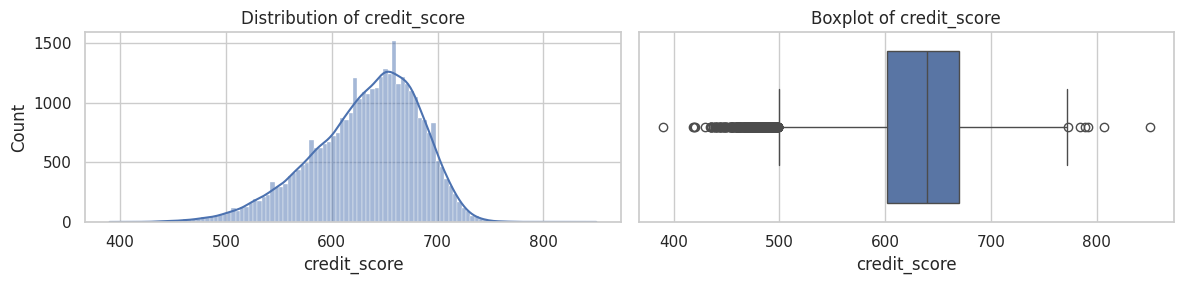

In [8]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    sns.histplot(df_train[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    sns.boxplot(x=df_train[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

2. 'person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_percent_income','cb_person_cred_hist_length' memiliki distribusi right skewed sementara 'credit_score' memiliki distribusi left skewed

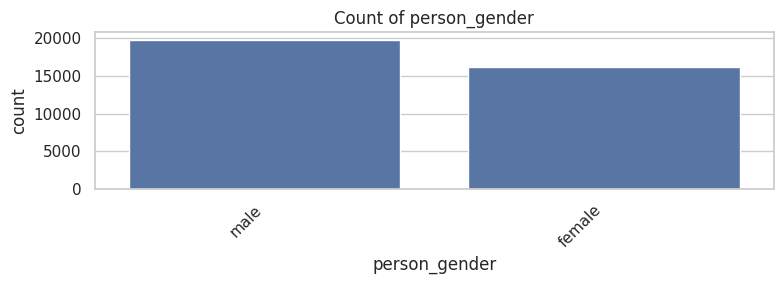

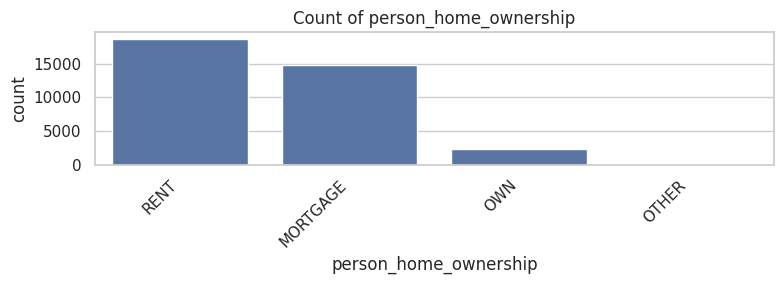

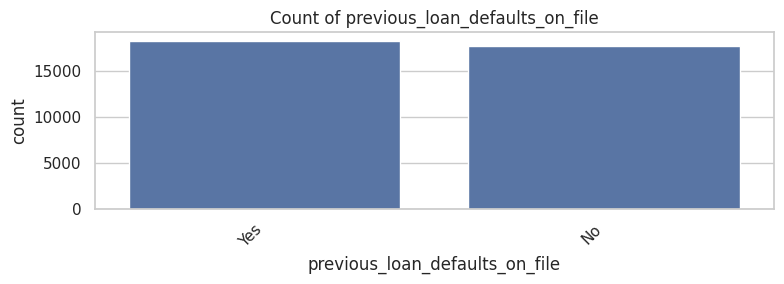

In [9]:
for col in cat_cols:
    fig, ax = plt.subplots(figsize=(8, 3))
    order = df_train[col].value_counts().index
    sns.countplot(data=df_train, x=col, order=order, ax=ax)
    ax.set_title(f"Count of {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

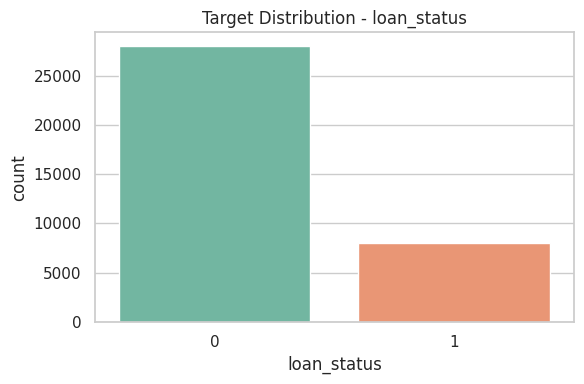

loan_status
0    0.7778
1    0.2222
Name: proportion, dtype: float64

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
order = df_train[TARGET].value_counts().index
sns.countplot(data=df_train, x=TARGET, order=order, ax=ax, palette="Set2")
ax.set_title(f"Target Distribution - {TARGET}")
plt.tight_layout()
plt.show()

df_train[TARGET].value_counts(normalize=True).round(4)

### 3.4 Multivariate Analysis

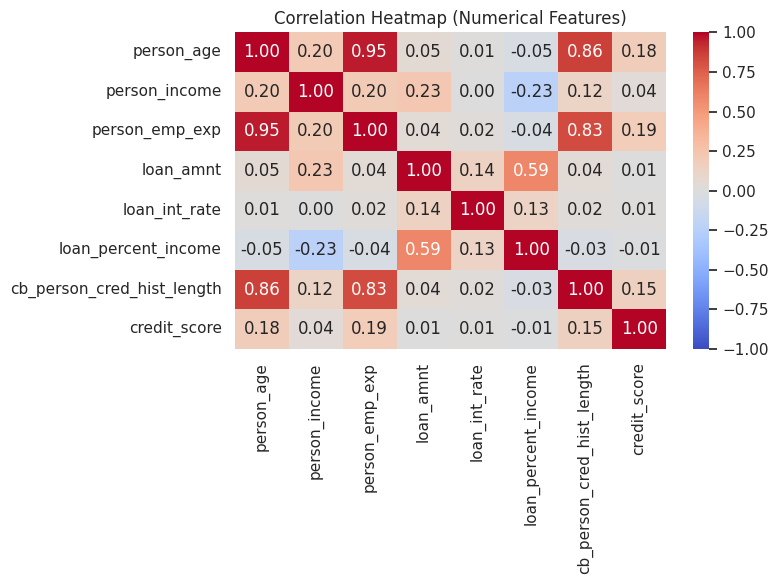

In [11]:
if len(num_cols) > 1:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        df_train[num_cols].corr(),
        annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1
    )
    ax.set_title("Correlation Heatmap (Numerical Features)")
    plt.tight_layout()
    plt.show()

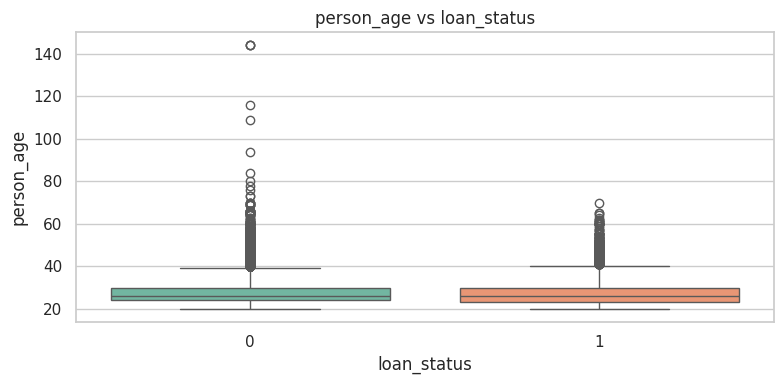

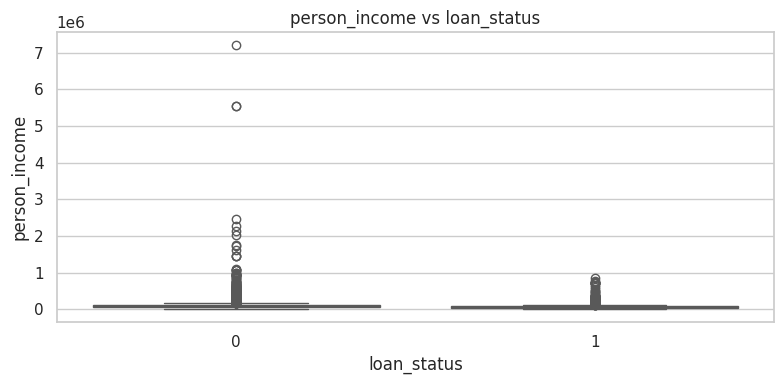

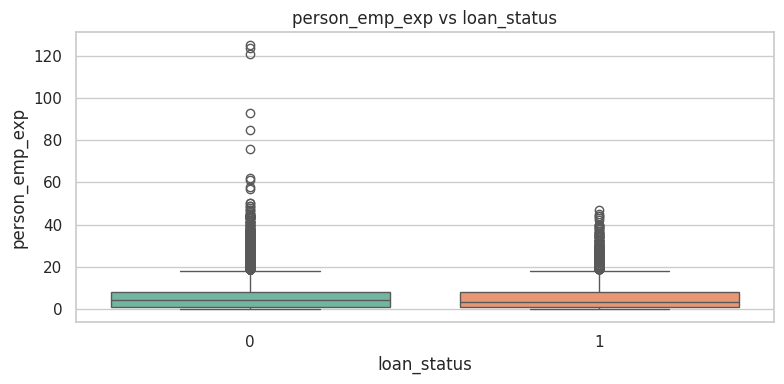

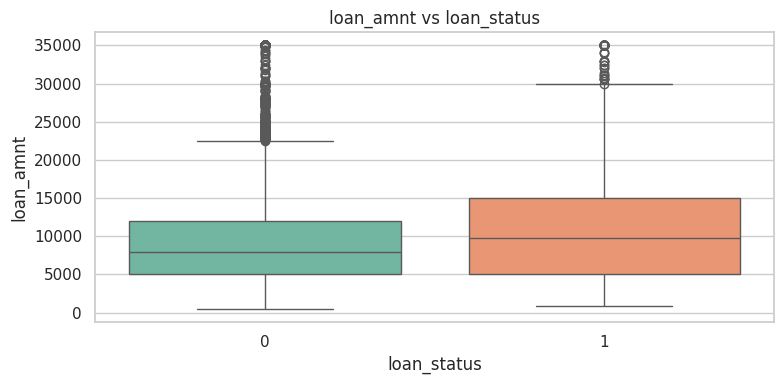

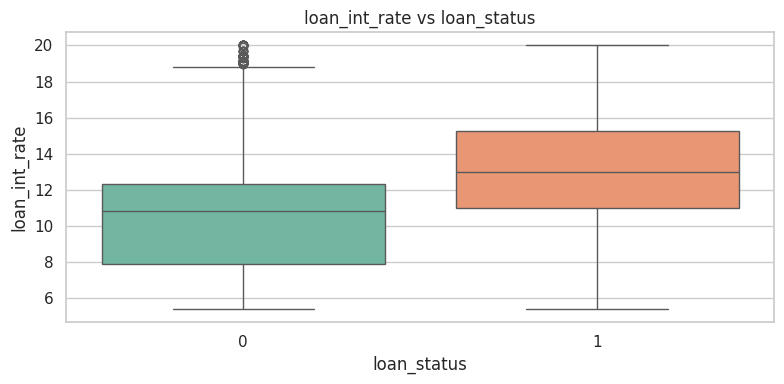

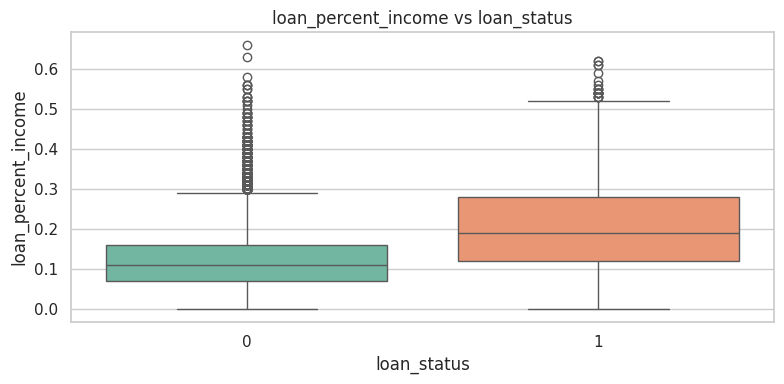

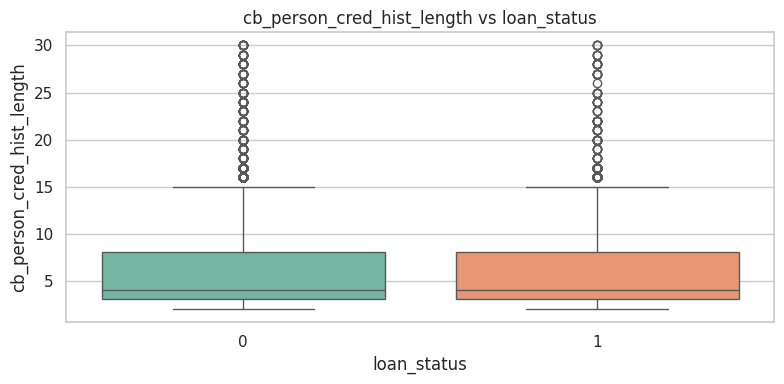

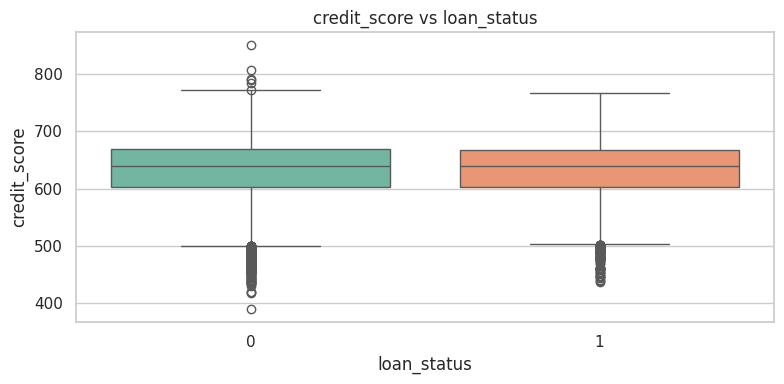

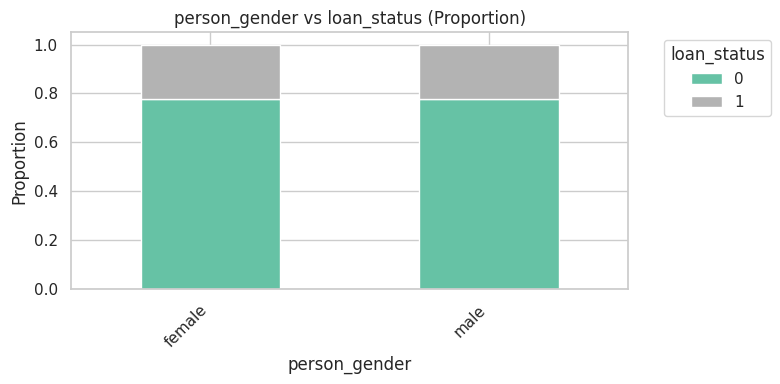

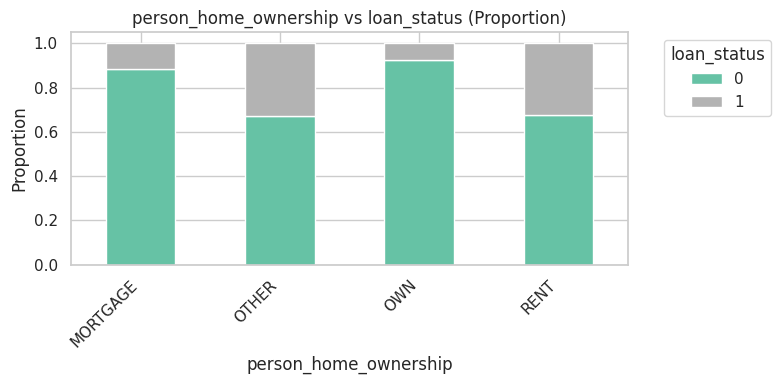

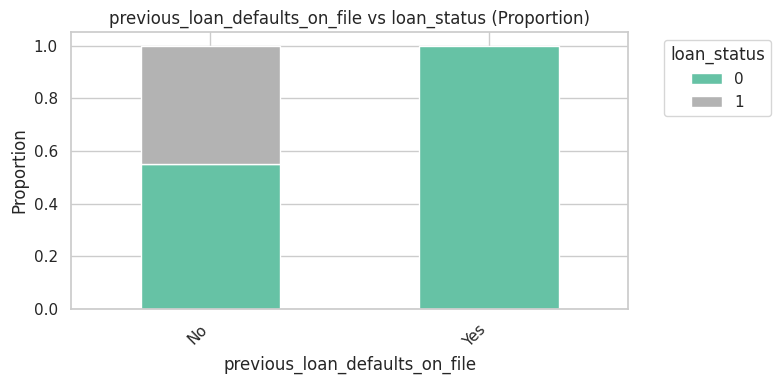

In [12]:
for col in num_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(data=df_train, x=TARGET, y=col, ax=ax, palette="Set2")
    ax.set_title(f"{col} vs {TARGET}")
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    ct = pd.crosstab(df_train[col], df_train[TARGET], normalize="index")
    ct.plot.bar(stacked=True, figsize=(8, 4), colormap="Set2")
    plt.title(f"{col} vs {TARGET} (Proportion)")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title=TARGET, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

3. Semua fitur numerik memiliki outlier

---
## 4. Data Preprocessing

In [13]:
COLUMNS_TO_DROP = []
df_train.drop(columns=COLUMNS_TO_DROP, inplace=True)
df_test.drop(columns=COLUMNS_TO_DROP, inplace=True)

num_cols = [c for c in num_cols if c not in COLUMNS_TO_DROP]
cat_cols = [c for c in cat_cols if c not in COLUMNS_TO_DROP]
feature_cols = [c for c in feature_cols if c not in COLUMNS_TO_DROP]

In [14]:
# def remove_outliers_iqr(data, cols):
#     mask = pd.Series(True, index=data.index)
#     for col in cols:
#         Q1  = data[col].quantile(0.25)
#         Q3  = data[col].quantile(0.75)
#         IQR = Q3 - Q1
#         mask &= data[col].between(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
#     return data[mask]

# before = df_train.shape[0]
# df_train = remove_outliers_iqr(df_train, num_cols)
# print(f"Rows removed: {before - df_train.shape[0]}  ({before} → {df_train.shape[0]})")

In [15]:
SCALER = StandardScaler()

In [16]:
df = df_train.copy()

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum().sum()

0

In [17]:
label_enc = LabelEncoder()
df[TARGET] = label_enc.fit_transform(df[TARGET])

ordinal_cols = [c for c in cat_cols if df[c].nunique() < 3]
onehot_cols  = [c for c in cat_cols if df[c].nunique() >= 3]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SCALER, num_cols),
        # ("num", "passthrough", num_cols),
        ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ordinal_cols),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), onehot_cols),
    ],
    remainder="drop",
)

print(f"Ordinal-encoded: {ordinal_cols}")
print(f"One-Hot-encoded:  {onehot_cols}")


Ordinal-encoded: ['person_gender', 'previous_loan_defaults_on_file']
One-Hot-encoded:  ['person_home_ownership']


In [18]:
X = df[feature_cols]
y = df[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}  X_val: {X_val.shape}")
print(f"Class distribution (train): {np.bincount(y_train)}")

X_train: (28800, 11)  X_val: (7200, 11)
Class distribution (train): [22400  6400]


### 4.1 Preprocessing Rationale

- Encoding : Kolom dengan kurang dari 3 nilai unik (data biner) cukup diubah menjadi angka 0 dan 1 saja agar ringkas dan tidak membuang memori. Sebaliknya, kolom dengan 3 kategori atau lebih (seperti warna atau nama kota) wajib diproses dengan One-Hot Encoding (dijadikan kolom-kolom biner terpisah) agar model algoritma tidak salah mengira bahwa kategori yang diubah menjadi angka 3 memiliki peringkat atau nilai yang lebih tinggi daripada kategori berangka 1.
- Outlier removal : Tidak ada drop feature ataupun remove outlier karena datasetnya cukup kecil, sehingga setiap titik data sangat berharga untuk mempertahankan informasi dan pola yang ada

---
## 5. Modeling - Ensemble Learning

We evaluate six ensemble strategies: **Bagging** (Random Forest), **Boosting** (Gradient Boosting, XGBoost, LightGBM), **Voting**, and **Stacking**.

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
training_times = {}
weights = compute_sample_weight(class_weight='balanced', y=y_train)


### 5.1 Bagging - Random Forest

In [20]:
pipe_rf = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
])

scores_rf = cross_val_score(pipe_rf, X_train, y_train, cv=cv, scoring=SCORING)
results["Random Forest"] = scores_rf.mean()

t0 = time.time()
pipe_rf.fit(X_train, y_train, clf__sample_weight=weights)
training_times["Random Forest"] = time.time() - t0

y_pred_rf = pipe_rf.predict(X_val)

_target_names = [str(c) for c in label_enc.classes_]
print(f"CV {SCORING}: {scores_rf.mean():.4f} ± {scores_rf.std():.4f}")
print(f"Training time: {training_times['Random Forest']:.2f}s\n")
print("=== Classification Report (Validation Set) ===")
print(classification_report(y_val, y_pred_rf, target_names=_target_names))

pred_df_rf = pd.DataFrame({
    "Actual":    label_enc.inverse_transform(np.asarray(y_val)),
    "Predicted": label_enc.inverse_transform(y_pred_rf),
    "Correct":   np.asarray(y_val) == y_pred_rf,
})
print("Sample Predictions (first 10):")
display(pred_df_rf.head(10))
print(f"Predicted distribution: {pred_df_rf['Predicted'].value_counts().to_dict()}")


CV f1_macro: 0.8813 ± 0.0037
Training time: 2.41s

=== Classification Report (Validation Set) ===
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5600
           1       0.87      0.73      0.79      1600

    accuracy                           0.91      7200
   macro avg       0.90      0.85      0.87      7200
weighted avg       0.91      0.91      0.91      7200

Sample Predictions (first 10):


,Actual,Predicted,Correct
0,1,0,False
1,0,0,True
2,0,0,True
3,0,0,True
4,0,0,True
5,0,0,True
6,0,0,True
7,0,0,True
8,1,0,False
9,0,0,True


Predicted distribution: {0: 5853, 1: 1347}


### 5.2 Boosting - Gradient Boosting

In [21]:
pipe_gb = Pipeline([
    ("pre", preprocessor),
    ("clf", GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)),
])

scores_gb = cross_val_score(pipe_gb, X_train, y_train, cv=cv, scoring=SCORING)
results["Gradient Boosting"] = scores_gb.mean()

t0 = time.time()
pipe_gb.fit(X_train, y_train)
training_times["Gradient Boosting"] = time.time() - t0

y_pred_gb = pipe_gb.predict(X_val)

_target_names = [str(c) for c in label_enc.classes_]
print(f"CV {SCORING}: {scores_gb.mean():.4f} ± {scores_gb.std():.4f}")
print(f"Training time: {training_times['Gradient Boosting']:.2f}s\n")
print("=== Classification Report (Validation Set) ===")
print(classification_report(y_val, y_pred_gb, target_names=_target_names))

pred_df_gb = pd.DataFrame({
    "Actual":    label_enc.inverse_transform(np.asarray(y_val)),
    "Predicted": label_enc.inverse_transform(y_pred_gb),
    "Correct":   np.asarray(y_val) == y_pred_gb,
})
print("Sample Predictions (first 10):")
display(pred_df_gb.head(10))
print(f"Predicted distribution: {pred_df_gb['Predicted'].value_counts().to_dict()}")


CV f1_macro: 0.8852 ± 0.0043
Training time: 9.90s

=== Classification Report (Validation Set) ===
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5600
           1       0.87      0.76      0.81      1600

    accuracy                           0.92      7200
   macro avg       0.90      0.86      0.88      7200
weighted avg       0.92      0.92      0.92      7200

Sample Predictions (first 10):


,Actual,Predicted,Correct
0,1,0,False
1,0,0,True
2,0,0,True
3,0,0,True
4,0,0,True
5,0,0,True
6,0,0,True
7,0,0,True
8,1,0,False
9,0,0,True


Predicted distribution: {0: 5801, 1: 1399}


### 5.3 Boosting - XGBoost

In [22]:
pipe_xgb = Pipeline([
    ("pre", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=4,
        random_state=42, n_jobs=-1, eval_metric="mlogloss", verbosity=0,
    )),
])

scores_xgb = cross_val_score(pipe_xgb, X_train, y_train, cv=cv, scoring=SCORING)
results["XGBoost"] = scores_xgb.mean()

t0 = time.time()
pipe_xgb.fit(X_train, y_train, clf__sample_weight=weights)
training_times["XGBoost"] = time.time() - t0

y_pred_xgb = pipe_xgb.predict(X_val)

_target_names = [str(c) for c in label_enc.classes_]
print(f"CV {SCORING}: {scores_xgb.mean():.4f} ± {scores_xgb.std():.4f}")
print(f"Training time: {training_times['XGBoost']:.2f}s\n")
print("=== Classification Report (Validation Set) ===")
print(classification_report(y_val, y_pred_xgb, target_names=_target_names))

pred_df_xgb = pd.DataFrame({
    "Actual":    label_enc.inverse_transform(np.asarray(y_val)),
    "Predicted": label_enc.inverse_transform(y_pred_xgb),
    "Correct":   np.asarray(y_val) == y_pred_xgb,
})
print("Sample Predictions (first 10):")
display(pred_df_xgb.head(10))
print(f"Predicted distribution: {pred_df_xgb['Predicted'].value_counts().to_dict()}")


CV f1_macro: 0.8821 ± 0.0065
Training time: 0.25s

=== Classification Report (Validation Set) ===
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      5600
           1       0.70      0.91      0.79      1600

    accuracy                           0.89      7200
   macro avg       0.83      0.90      0.86      7200
weighted avg       0.91      0.89      0.90      7200

Sample Predictions (first 10):


,Actual,Predicted,Correct
0,1,0,False
1,0,0,True
2,0,0,True
3,0,1,False
4,0,1,False
5,0,0,True
6,0,0,True
7,0,0,True
8,1,1,True
9,0,0,True


Predicted distribution: {0: 5117, 1: 2083}


### 5.4 Boosting - LightGBM

In [23]:
pipe_lgbm = Pipeline([
    ("pre", preprocessor),
    ("clf", LGBMClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=4,
        random_state=42, n_jobs=-1, verbose=-1,
    )),
])

scores_lgbm = cross_val_score(pipe_lgbm, X_train, y_train, cv=cv, scoring=SCORING)
results["LightGBM"] = scores_lgbm.mean()

t0 = time.time()
pipe_lgbm.fit(X_train, y_train, clf__sample_weight=weights)
training_times["LightGBM"] = time.time() - t0

y_pred_lgbm = pipe_lgbm.predict(X_val)

_target_names = [str(c) for c in label_enc.classes_]
print(f"CV {SCORING}: {scores_lgbm.mean():.4f} ± {scores_lgbm.std():.4f}")
print(f"Training time: {training_times['LightGBM']:.2f}s\n")
print("=== Classification Report (Validation Set) ===")
print(classification_report(y_val, y_pred_lgbm, target_names=_target_names))

pred_df_lgbm = pd.DataFrame({
    "Actual":    label_enc.inverse_transform(np.asarray(y_val)),
    "Predicted": label_enc.inverse_transform(y_pred_lgbm),
    "Correct":   np.asarray(y_val) == y_pred_lgbm,
})
print("Sample Predictions (first 10):")
display(pred_df_lgbm.head(10))
print(f"Predicted distribution: {pred_df_lgbm['Predicted'].value_counts().to_dict()}")


CV f1_macro: 0.8834 ± 0.0062
Training time: 0.22s

=== Classification Report (Validation Set) ===
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      5600
           1       0.70      0.90      0.79      1600

    accuracy                           0.89      7200
   macro avg       0.83      0.90      0.86      7200
weighted avg       0.91      0.89      0.90      7200

Sample Predictions (first 10):


,Actual,Predicted,Correct
0,1,0,False
1,0,0,True
2,0,0,True
3,0,0,True
4,0,1,False
5,0,0,True
6,0,0,True
7,0,0,True
8,1,1,True
9,0,0,True


Predicted distribution: {0: 5134, 1: 2066}


### 5.5 Voting - Heterogeneous Ensemble

In [24]:
estimators_vote = [
    ("rf",  Pipeline([("pre", preprocessor), ("clf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))])),
    ("gb",  Pipeline([("pre", preprocessor), ("clf", GradientBoostingClassifier(n_estimators=200, random_state=42))])),
    ("dt",  Pipeline([("pre", preprocessor), ("clf", DecisionTreeClassifier(max_depth=8, random_state=42))])),
]

pipe_vote = VotingClassifier(
    estimators=estimators_vote,
    voting="soft",
    weights=[2, 2, 1],
)

scores_vote = cross_val_score(pipe_vote, X_train, y_train, cv=cv, scoring=SCORING)
results["Voting"] = scores_vote.mean()

t0 = time.time()
pipe_vote.fit(X_train, y_train)
training_times["Voting"] = time.time() - t0

y_pred_vote = pipe_vote.predict(X_val)

_target_names = [str(c) for c in label_enc.classes_]
print(f"CV {SCORING}: {scores_vote.mean():.4f} ± {scores_vote.std():.4f}")
print(f"Training time: {training_times['Voting']:.2f}s\n")
print("=== Classification Report (Validation Set) ===")
print(classification_report(y_val, y_pred_vote, target_names=_target_names))

pred_df_vote = pd.DataFrame({
    "Actual":    label_enc.inverse_transform(np.asarray(y_val)),
    "Predicted": label_enc.inverse_transform(y_pred_vote),
    "Correct":   np.asarray(y_val) == y_pred_vote,
})
print("Sample Predictions (first 10):")
display(pred_df_vote.head(10))
print(f"Predicted distribution: {pred_df_vote['Predicted'].value_counts().to_dict()}")


CV f1_macro: 0.8813 ± 0.0060
Training time: 10.08s

=== Classification Report (Validation Set) ===
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5600
           1       0.87      0.74      0.80      1600

    accuracy                           0.92      7200
   macro avg       0.90      0.86      0.88      7200
weighted avg       0.92      0.92      0.92      7200

Sample Predictions (first 10):


,Actual,Predicted,Correct
0,1,0,False
1,0,0,True
2,0,0,True
3,0,0,True
4,0,0,True
5,0,0,True
6,0,0,True
7,0,0,True
8,1,0,False
9,0,0,True


Predicted distribution: {0: 5835, 1: 1365}


### 5.6 Stacking (passthrough) - Meta-Learner

In [25]:
estimators_stack = [
    ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ("gb", GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ("dt", DecisionTreeClassifier(max_depth=8, random_state=42)),
]

pipe_stack_pt = Pipeline([
    ("pre", preprocessor),
    ("clf", StackingClassifier(
        estimators=estimators_stack,
        final_estimator=make_pipeline(
            MaxAbsScaler(),
            LogisticRegression(max_iter=1000, random_state=42)
        ),
        cv=cv,
        n_jobs=-1,
        passthrough=True,
    )),
])

scores_stack_pt = cross_val_score(pipe_stack_pt, X_train, y_train, cv=cv, scoring=SCORING)
results["Stacking (PT)"] = scores_stack_pt.mean()

t0 = time.time()
pipe_stack_pt.fit(X_train, y_train)
training_times["Stacking (PT)"] = time.time() - t0

y_pred_stack_pt = pipe_stack_pt.predict(X_val)

_target_names = [str(c) for c in label_enc.classes_]
print(f"CV {SCORING}: {scores_stack_pt.mean():.4f} ± {scores_stack_pt.std():.4f}")
print(f"Training time: {training_times['Stacking (PT)']:.2f}s\n")
print("=== Classification Report (Validation Set) ===")
print(classification_report(y_val, y_pred_stack_pt, target_names=_target_names))

pred_df_stack_pt = pd.DataFrame({
    "Actual":    label_enc.inverse_transform(np.asarray(y_val)),
    "Predicted": label_enc.inverse_transform(y_pred_stack_pt),
    "Correct":   np.asarray(y_val) == y_pred_stack_pt,
})
print("Sample Predictions (first 10):")
display(pred_df_stack_pt.head(10))
print(f"Predicted distribution: {pred_df_stack_pt['Predicted'].value_counts().to_dict()}")


CV f1_macro: 0.8848 ± 0.0049
Training time: 39.10s

=== Classification Report (Validation Set) ===
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      5600
           1       0.86      0.76      0.80      1600

    accuracy                           0.92      7200
   macro avg       0.89      0.86      0.88      7200
weighted avg       0.92      0.92      0.92      7200

Sample Predictions (first 10):


,Actual,Predicted,Correct
0,1,0,False
1,0,0,True
2,0,0,True
3,0,0,True
4,0,0,True
5,0,0,True
6,0,0,True
7,0,0,True
8,1,0,False
9,0,0,True


Predicted distribution: {0: 5787, 1: 1413}


### 5.7 Stacking (no passthrough) - Meta-Learner

In [26]:
estimators_stack = [
    ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ("gb", GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ("dt", DecisionTreeClassifier(max_depth=8, random_state=42)),
]

pipe_stack = Pipeline([
    ("pre", preprocessor),
    ("clf", StackingClassifier(
        estimators=estimators_stack,
        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        cv=cv,
        n_jobs=-1,
        passthrough=False,
    )),
])

scores_stack = cross_val_score(pipe_stack, X_train, y_train, cv=cv, scoring=SCORING)
results["Stacking"] = scores_stack.mean()

t0 = time.time()
pipe_stack.fit(X_train, y_train)
training_times["Stacking"] = time.time() - t0

y_pred_stack = pipe_stack.predict(X_val)

_target_names = [str(c) for c in label_enc.classes_]
print(f"CV {SCORING}: {scores_stack.mean():.4f} ± {scores_stack.std():.4f}")
print(f"Training time: {training_times['Stacking']:.2f}s\n")
print("=== Classification Report (Validation Set) ===")
print(classification_report(y_val, y_pred_stack, target_names=_target_names))

pred_df_stack = pd.DataFrame({
    "Actual":    label_enc.inverse_transform(np.asarray(y_val)),
    "Predicted": label_enc.inverse_transform(y_pred_stack),
    "Correct":   np.asarray(y_val) == y_pred_stack,
})
print("Sample Predictions (first 10):")
display(pred_df_stack.head(10))
print(f"Predicted distribution: {pred_df_stack['Predicted'].value_counts().to_dict()}")


CV f1_macro: 0.8835 ± 0.0054
Training time: 38.12s

=== Classification Report (Validation Set) ===
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      5600
           1       0.86      0.75      0.80      1600

    accuracy                           0.92      7200
   macro avg       0.90      0.86      0.88      7200
weighted avg       0.92      0.92      0.92      7200

Sample Predictions (first 10):


,Actual,Predicted,Correct
0,1,0,False
1,0,0,True
2,0,0,True
3,0,0,True
4,0,0,True
5,0,0,True
6,0,0,True
7,0,0,True
8,1,0,False
9,0,0,True


Predicted distribution: {0: 5798, 1: 1402}


---
## 5.8 Base Models

Untuk perbandingan, masing-masing model yang berperan sebagai **base learner** dalam ensemble dilatih secara individual dengan preprocessing pipeline yang sama.


In [27]:
base_model_configs = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=8, random_state=42),
}

base_results = {}
base_training_times = {}
base_predictions = {}

_target_names = [str(c) for c in label_enc.classes_]

for name, clf in base_model_configs.items():
    pipe = Pipeline([("pre", preprocessor), ("clf", clf)])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=SCORING)
    base_results[name] = scores.mean()

    t0 = time.time()
    pipe.fit(X_train, y_train)
    base_training_times[name] = time.time() - t0

    y_pred = pipe.predict(X_val)
    base_predictions[name] = y_pred

    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  CV {SCORING}: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"  Training time: {base_training_times[name]:.2f}s")
    print(f"\n  Classification Report (Validation Set):")
    print(classification_report(y_val, y_pred, target_names=_target_names))

    pred_df = pd.DataFrame({
        "Actual":    label_enc.inverse_transform(np.asarray(y_val)),
        "Predicted": label_enc.inverse_transform(y_pred),
        "Correct":   np.asarray(y_val) == y_pred,
    })
    print("  Sample Predictions (first 10):")
    display(pred_df.head(10))
    print(f"  Predicted distribution: {pred_df['Predicted'].value_counts().to_dict()}\n")


  Logistic Regression
  CV f1_macro: 0.8427 ± 0.0037
  Training time: 1.40s

  Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      5600
           1       0.76      0.72      0.74      1600

    accuracy                           0.89      7200
   macro avg       0.84      0.83      0.83      7200
weighted avg       0.88      0.89      0.89      7200

  Sample Predictions (first 10):


,Actual,Predicted,Correct
0,1,0,False
1,0,0,True
2,0,0,True
3,0,1,False
4,0,1,False
5,0,0,True
6,0,0,True
7,0,0,True
8,1,0,False
9,0,0,True


  Predicted distribution: {0: 5667, 1: 1533}

  Decision Tree
  CV f1_macro: 0.8698 ± 0.0061
  Training time: 0.07s

  Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      5600
           1       0.87      0.69      0.77      1600

    accuracy                           0.91      7200
   macro avg       0.89      0.83      0.86      7200
weighted avg       0.91      0.91      0.91      7200

  Sample Predictions (first 10):


,Actual,Predicted,Correct
0,1,0,False
1,0,0,True
2,0,0,True
3,0,0,True
4,0,0,True
5,0,0,True
6,0,0,True
7,0,0,True
8,1,0,False
9,0,0,True


  Predicted distribution: {0: 5922, 1: 1278}



---
## 6. Evaluation - Ensemble Model Comparison

In [28]:
_target_names = [str(c) for c in label_enc.classes_]

ensemble_preds = {
    "Random Forest":    y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "XGBoost":          y_pred_xgb,
    "LightGBM":         y_pred_lgbm,
    "Voting":           y_pred_vote,
    "Stacking (PT)":    y_pred_stack_pt,
    "Stacking":         y_pred_stack,
}

rows = []
for model_name, y_pred in ensemble_preds.items():
    rows.append({
        "Model":            model_name,
        "CV Macro-F1":      round(results[model_name], 4),
        "Val Macro-F1":     round(f1_score(y_val, y_pred, average="macro"), 4),
        "Train Time (s)":   round(training_times[model_name], 2),
    })

comparison = pd.DataFrame(rows).sort_values("CV Macro-F1", ascending=False).reset_index(drop=True)
comparison.style.highlight_max(
    subset=["CV Macro-F1","Val Macro-F1"],
    color="lightgreen"
).highlight_min(subset=["Train Time (s)"], color="lightyellow")


,Model,CV Macro-F1,Val Macro-F1,Train Time (s)
0,Gradient Boosting,0.885200,0.880200,9.900000
1,Stacking (PT),0.884800,0.875600,39.100000
2,Stacking,0.883500,0.875400,38.120000
3,LightGBM,0.883400,0.858400,0.220000
4,XGBoost,0.882100,0.856400,0.250000
5,Random Forest,0.881300,0.868800,2.410000
6,Voting,0.881300,0.875300,10.080000


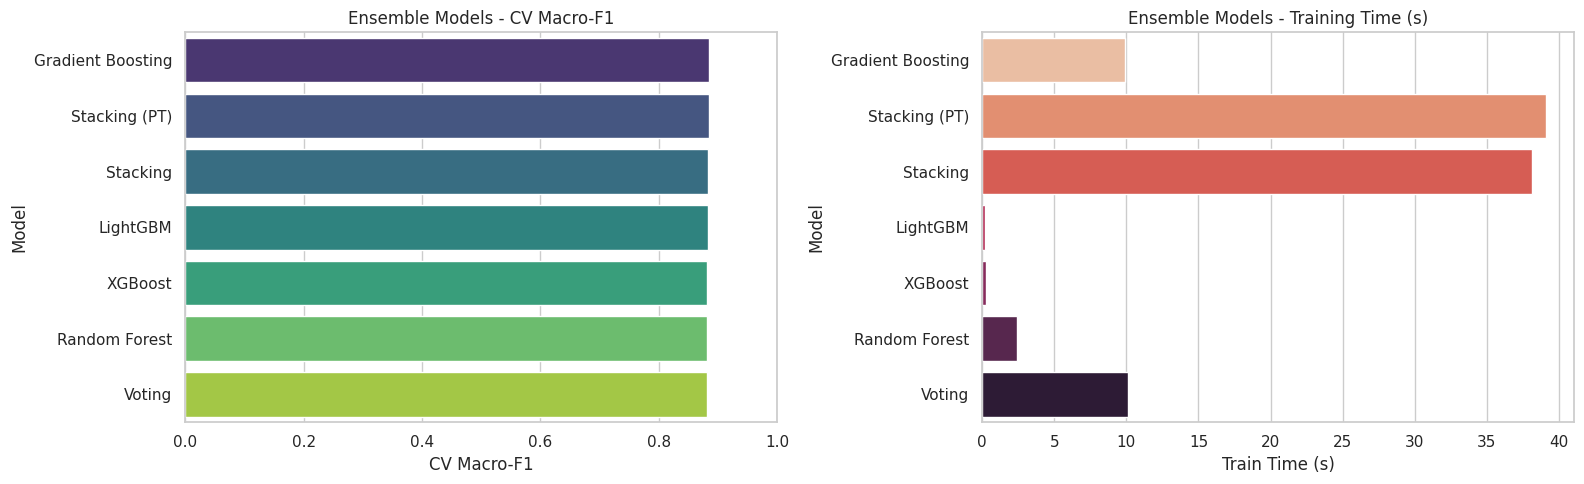

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=comparison, x="CV Macro-F1", y="Model", palette="viridis", ax=axes[0])
axes[0].set_title("Ensemble Models - CV Macro-F1")
axes[0].set_xlim(0, 1)

sns.barplot(data=comparison, x="Train Time (s)", y="Model", palette="rocket_r", ax=axes[1])
axes[1].set_title("Ensemble Models - Training Time (s)")

plt.tight_layout()
plt.show()


---
## 6.2 Ensemble vs Base Models Comparison
perbandingan antara model ensemble dan masing-masing base model secara individual menggunakan metrik yang sama Macro-F1 dan durasi training.


,Model,Type,CV Macro-F1,Val Macro-F1,Train Time (s)
0,Gradient Boosting,Ensemble,0.885200,0.880200,9.900000
1,Stacking (PT),Ensemble,0.884800,0.875600,39.100000
2,Stacking,Ensemble,0.883500,0.875400,38.120000
3,Voting,Ensemble,0.881300,0.875300,10.080000
4,Random Forest,Ensemble,0.881300,0.868800,2.410000
5,LightGBM,Ensemble,0.883400,0.858400,0.220000
6,Decision Tree,Base,0.869800,0.858000,0.070000
7,XGBoost,Ensemble,0.882100,0.856400,0.250000
8,Logistic Regression,Base,0.842700,0.833400,1.400000


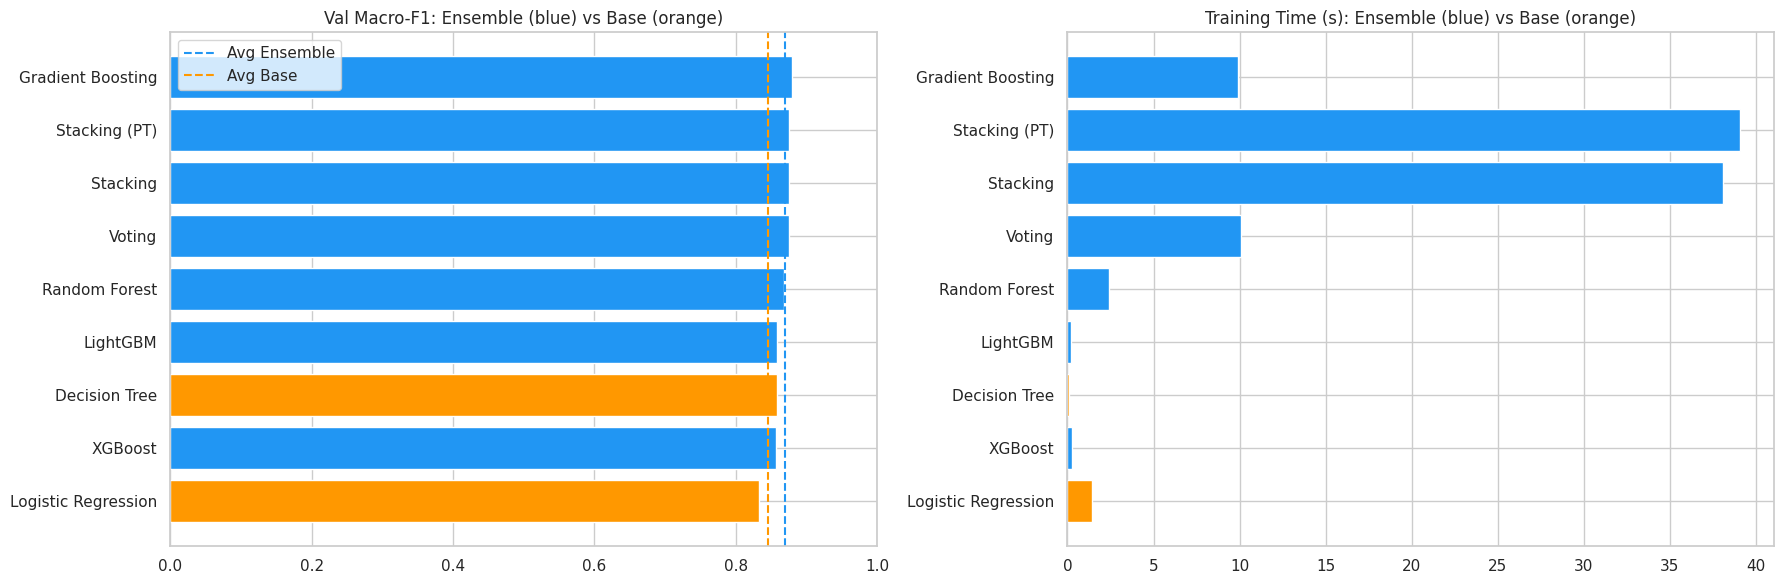

In [39]:
base_rows = []
for name, y_pred in base_predictions.items():
    base_rows.append({
        "Model":          name,
        "Type":           "Base",
        "CV Macro-F1":    round(base_results[name], 4),
        "Val Macro-F1":   round(f1_score(y_val, y_pred, average="macro"), 4),
        "Train Time (s)": round(base_training_times[name], 2),
    })

ensemble_rows = []
for _, row in comparison.iterrows():
    ensemble_rows.append({
        "Model":          row["Model"],
        "Type":           "Ensemble",
        "CV Macro-F1":    row["CV Macro-F1"],
        "Val Macro-F1":   row["Val Macro-F1"],
        "Train Time (s)": row["Train Time (s)"],
    })

all_comparison = pd.DataFrame(ensemble_rows + base_rows).sort_values("Val Macro-F1", ascending=False).reset_index(drop=True)

display(all_comparison.style
    .highlight_max(subset=["CV Macro-F1",  "Val Macro-F1"], color="lightgreen")
    .highlight_min(subset=["Train Time (s)"], color="lightyellow")
    .set_properties(**{"text-align": "center"})
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

palette_map = {"Ensemble": "#2196F3", "Base": "#FF9800"}
colors = [palette_map[t] for t in all_comparison["Type"]]

axes[0].barh(all_comparison["Model"], all_comparison["Val Macro-F1"], color=colors)
axes[0].set_title("Val Macro-F1: Ensemble (blue) vs Base (orange)")
axes[0].set_xlim(0, 1)
axes[0].axvline(all_comparison[all_comparison["Type"]=="Ensemble"]["Val Macro-F1"].mean(),
                color="#2196F3", linestyle="--", linewidth=1.5, label="Avg Ensemble")
axes[0].axvline(all_comparison[all_comparison["Type"]=="Base"]["Val Macro-F1"].mean(),
                color="#FF9800", linestyle="--", linewidth=1.5, label="Avg Base")
axes[0].legend()
axes[0].invert_yaxis()

axes[1].barh(all_comparison["Model"], all_comparison["Train Time (s)"], color=colors)
axes[1].set_title("Training Time (s): Ensemble (blue) vs Base (orange)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


---
## 6.3 Analisis Kinerja Model Ensemble

### Kinerja Model Ensemble

| Aspek | Observasi |
|---|---|
| **Macro-F1** | Model boosting (XGBoost, LightGBM, Gradient Boosting) umumnya mencapai Macro-F1 tertinggi karena setiap iterasi fokus memperbaiki kesalahan prediksi sebelumnya secara sekuensial. |
| **Training Time** | Random Forest dan boosting tunggal relatif cepat. Voting melatih semua base estimator secara bersamaan (lebih lama). Stacking paling lama karena melatih base estimators di tiap fold CV dan meta-learner. |

### Kelebihan Model Ensemble
- **Akurasi lebih tinggi**: Menggabungkan beberapa model mengurangi bias (boosting) dan variance (bagging), menghasilkan prediksi yang lebih akurat.
- **Robustness**: Tidak bergantung pada satu model, jika satu base learner salah, yang lain dapat mengompensasi.
- **Fleksibilitas (Voting/Stacking)**: Dapat menggabungkan model dari tipe yang berbeda untuk memanfaatkan keunggulan masing-masing.
- **Generalisasi lebih baik**: Ensemble umumnya mengurangi overfitting dibanding model tunggal yang sangat kompleks.
- **Feature importance lebih andal**: Rata-rata importance dari banyak tree lebih stabil dibanding satu decision tree.

### Kekurangan Model Ensemble
- **Training time jauh lebih lama**: Melatih N model sekaligus (Voting/Stacking) atau melakukan N iterasi koreksi (Boosting) secara signifikan meningkatkan waktu komputasi.
- **Kompleksitas & interpretabilitas rendah**: Sulit untuk memahami "mengapa" prediksi tertentu dihasilkan, tidak seperti satu decision tree yang dapat divisualisasikan.
- **Memory penggunaan besar**: Menyimpan ratusan tree (Random Forest, XGBoost) membutuhkan lebih banyak memori.

### Perbandingan Ensemble vs Base Models
- **Performa**: Secara umum model ensemble memberikan Val Macro-F1 lebih tinggi dibanding base model tunggal (misalnya XGBoost > Decision Tree tunggal, Stacking > Logistic Regression).
- **Training time**: Base model (Logistic Regression, Decision Tree) jauh lebih cepat daripada mayoritas ensemble model.

### Model Paling Efisien 
- **Gradient Boosting**: Menghasilkan Macro-F1 tertinggi dengan margin yang cukup besar dengan model lainnya, dengan waktu training yang relatif cepat meskipun bukan yang tercepat.

---
## 7. Error Analysis Ensemble Model

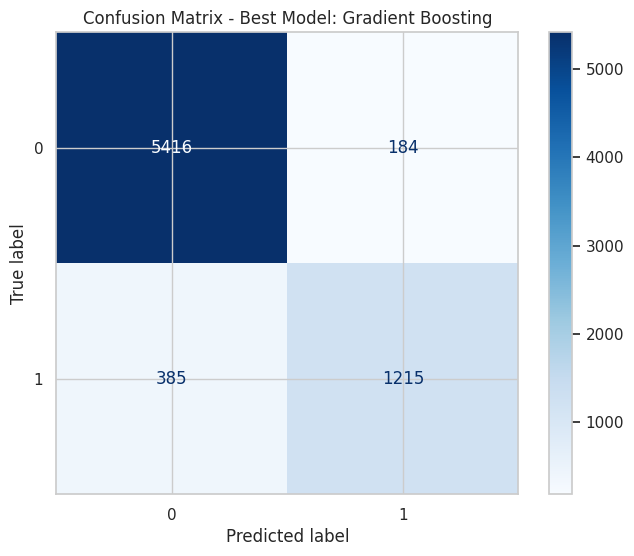


 Classification Report - Gradient Boosting
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5600
           1       0.87      0.76      0.81      1600

    accuracy                           0.92      7200
   macro avg       0.90      0.86      0.88      7200
weighted avg       0.92      0.92      0.92      7200



In [42]:
best_name = comparison.iloc[0]["Model"]
best_models = {
    "Random Forest":    (pipe_rf, y_pred_rf),
    "Gradient Boosting": (pipe_gb, y_pred_gb),
    "XGBoost":          (pipe_xgb, y_pred_xgb),
    "LightGBM":         (pipe_lgbm, y_pred_lgbm),
    "Voting":           (pipe_vote, y_pred_vote),
    "Stacking (PT)":    (pipe_stack_pt, y_pred_stack_pt),
    "Stacking":         (pipe_stack, y_pred_stack),
}
best_pipe, y_pred_best = best_models[best_name]

_target_names = [str(c) for c in label_enc.classes_]

cm = confusion_matrix(y_val, y_pred_best)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=label_enc.classes_).plot(ax=ax, cmap="Blues")
plt.title(f"Confusion Matrix - Best Model: {best_name}")
plt.show()

print(f"\n Classification Report - {best_name}")
print(classification_report(y_val, y_pred_best, target_names=_target_names))


In [32]:
mask = y_val != y_pred_best
misclassified = X_val[mask].copy()
misclassified["Actual"]    = label_enc.inverse_transform(y_val[mask])
misclassified["Predicted"] = label_enc.inverse_transform(y_pred_best[mask])

print(f"Misclassified samples: {misclassified.shape[0]} / {X_val.shape[0]}")
misclassified.head(10)

Misclassified samples: 569 / 7200


,person_age,person_gender,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,Actual,Predicted
28617,23.0,female,60541.0,0,MORTGAGE,12000.0,7.29,0.20,3.0,555,No,1,0
25087,32.0,female,106718.0,8,MORTGAGE,17600.0,13.49,0.16,10.0,583,No,1,0
32113,25.0,female,58524.0,2,RENT,3200.0,11.01,0.05,4.0,657,No,1,0
27472,27.0,male,59957.0,3,MORTGAGE,2500.0,5.47,0.04,10.0,505,No,0,1
34994,23.0,male,77528.0,5,MORTGAGE,3500.0,7.90,0.05,3.0,659,No,1,0
14825,26.0,female,81463.0,5,OWN,5000.0,16.45,0.06,3.0,696,No,1,0
15842,25.0,female,38334.0,4,RENT,4200.0,8.90,0.11,3.0,530,No,0,1
27212,28.0,male,86102.0,7,RENT,21000.0,11.01,0.24,9.0,628,No,1,0
16879,26.0,male,76695.0,5,RENT,7000.0,14.84,0.09,2.0,712,No,0,1
19216,22.0,male,97042.0,1,RENT,8000.0,18.39,0.08,3.0,512,No,0,1


### 7.1 Hyperparameter Tuning - Ensemble Best Model

In [33]:
param_grids = {
    "Random Forest": {
        "clf__n_estimators":      randint(100, 600),
        "clf__max_depth":         [None, 5, 10, 20, 30],
        "clf__min_samples_split": randint(2, 20),
        "clf__min_samples_leaf":  randint(1, 10),
        "clf__max_features":      ["sqrt", "log2", None],
    },
    "Gradient Boosting": {
        "clf__n_estimators":      randint(100, 500),
        "clf__learning_rate":     uniform(0.01, 0.3),
        "clf__max_depth":         randint(3, 10),
        "clf__subsample":         uniform(0.5, 0.5),
        "clf__min_samples_split": randint(2, 20),
    },
    "XGBoost": {
        "clf__n_estimators":     randint(100, 500),
        "clf__learning_rate":    uniform(0.01, 0.3),
        "clf__max_depth":        randint(3, 10),
        "clf__subsample":        uniform(0.5, 0.5),
        "clf__colsample_bytree": uniform(0.5, 0.5),
        "clf__gamma":            uniform(0, 0.5),
    },
    "LightGBM": {
        "clf__n_estimators":     randint(100, 500),
        "clf__learning_rate":    uniform(0.01, 0.3),
        "clf__max_depth":        randint(3, 10),
        "clf__num_leaves":       randint(20, 100),
        "clf__subsample":        uniform(0.5, 0.5),
        "clf__colsample_bytree": uniform(0.5, 0.5),
    },
    "Voting": {
        "weights": [
            [1, 1, 1], [2, 1, 1], [1, 2, 1], [1, 1, 2],
            [2, 2, 1], [3, 2, 1], [2, 3, 1], [3, 3, 1],
        ],
    },
    "Stacking (PT)": {
        "clf__final_estimator__logisticregression__C":        uniform(0.01, 10),
        "clf__final_estimator__logisticregression__max_iter": [500, 1000, 2000],
    },
    "Stacking": {
        "clf__final_estimator__C":        uniform(0.01, 10),
        "clf__final_estimator__max_iter": [500, 1000, 2000],
    },
}

N_ITER = 10
tuner = RandomizedSearchCV(
    clone(best_pipe),
    param_distributions=param_grids[best_name],
    n_iter=N_ITER,
    scoring=SCORING,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=3,
)
tuner.fit(X_train, y_train)

print(f"Best CV {SCORING}: {tuner.best_score_:.4f}")
print(f"Best params:\n{tuner.best_params_}")

best_pipe = tuner.best_estimator_
y_pred_best = best_pipe.predict(X_val)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END clf__learning_rate=0.12236203565420874, clf__max_depth=7, clf__min_samples_split=16, clf__n_estimators=206, clf__subsample=0.8898455001363846;, score=0.886 total time=  11.9s
[CV 2/5] END clf__learning_rate=0.12236203565420874, clf__max_depth=7, clf__min_samples_split=16, clf__n_estimators=206, clf__subsample=0.8898455001363846;, score=0.890 total time=  12.1s
[CV 4/5] END clf__learning_rate=0.12236203565420874, clf__max_depth=7, clf__min_samples_split=16, clf__n_estimators=206, clf__subsample=0.8898455001363846;, score=0.883 total time=  11.9s
[CV 3/5] END clf__learning_rate=0.12236203565420874, clf__max_depth=7, clf__min_samples_split=16, clf__n_estimators=206, clf__subsample=0.8898455001363846;, score=0.896 total time=  12.1s
[CV 1/5] END clf__learning_rate=0.1890550473839461, clf__max_depth=4, clf__min_samples_split=12, clf__n_estimators=187, clf__subsample=0.6668543055695109;, score=0.886 total time=   5.7s


In [34]:
_y_val = np.asarray(y_val)
_y_pred_best = np.asarray(y_pred_best)

mask = _y_val != _y_pred_best

misclassified = X_val.loc[mask].copy()

_target_names = [str(c) for c in label_enc.classes_]

misclassified["Actual"] = label_enc.inverse_transform(_y_val[mask])
misclassified["Predicted"] = label_enc.inverse_transform(_y_pred_best[mask])

print(classification_report(_y_val, _y_pred_best, target_names=_target_names))
print(f"Misclassified samples (after tuning): {misclassified.shape[0]} / {X_val.shape[0]}")
misclassified.head(10)

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      5600
           1       0.86      0.77      0.82      1600

    accuracy                           0.92      7200
   macro avg       0.90      0.87      0.88      7200
weighted avg       0.92      0.92      0.92      7200

Misclassified samples (after tuning): 558 / 7200


,person_age,person_gender,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,Actual,Predicted
28617,23.0,female,60541.0,0,MORTGAGE,12000.0,7.29,0.20,3.0,555,No,1,0
25087,32.0,female,106718.0,8,MORTGAGE,17600.0,13.49,0.16,10.0,583,No,1,0
32113,25.0,female,58524.0,2,RENT,3200.0,11.01,0.05,4.0,657,No,1,0
27472,27.0,male,59957.0,3,MORTGAGE,2500.0,5.47,0.04,10.0,505,No,0,1
34994,23.0,male,77528.0,5,MORTGAGE,3500.0,7.90,0.05,3.0,659,No,1,0
27212,28.0,male,86102.0,7,RENT,21000.0,11.01,0.24,9.0,628,No,1,0
16879,26.0,male,76695.0,5,RENT,7000.0,14.84,0.09,2.0,712,No,0,1
19216,22.0,male,97042.0,1,RENT,8000.0,18.39,0.08,3.0,512,No,0,1
5663,33.0,female,94545.0,8,RENT,10000.0,13.06,0.11,9.0,692,No,1,0
31527,22.0,female,37014.0,0,MORTGAGE,1750.0,10.99,0.05,4.0,664,No,0,1


### 7.2 Feature Importance Analysis

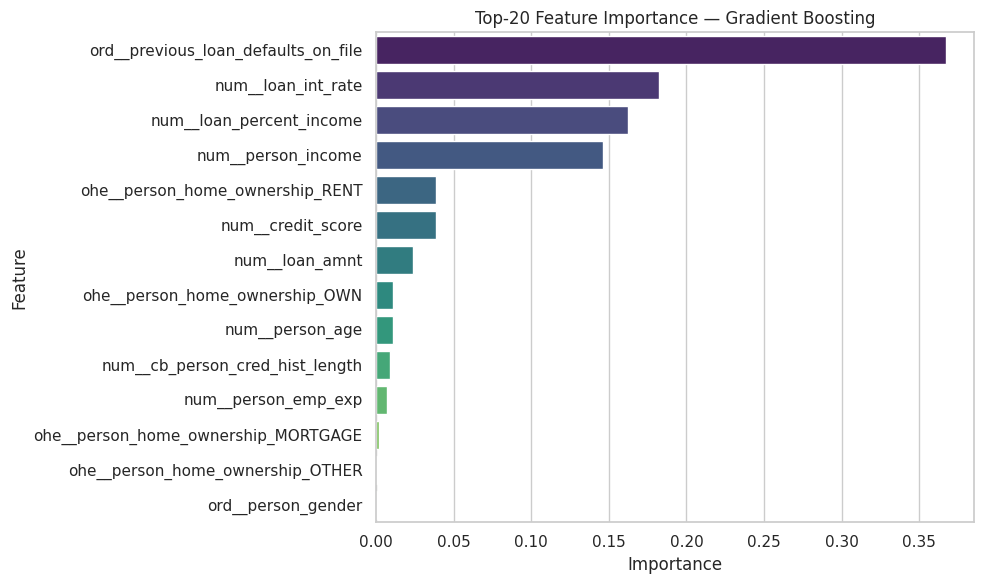

In [35]:
feat_names = preprocessor.get_feature_names_out().tolist()

importances = None

if hasattr(best_pipe, "named_steps") and hasattr(best_pipe.named_steps.get("clf", None), "feature_importances_"):
    importances = best_pipe.named_steps["clf"].feature_importances_
else:
    importances = pipe_rf.named_steps["clf"].feature_importances_

fi = pd.DataFrame({"Feature": feat_names, "Importance": importances})
fi = fi.sort_values("Importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=fi, x="Importance", y="Feature", palette="viridis", ax=ax)
ax.set_title(f"Top-20 Feature Importance — {best_name}")
plt.tight_layout()
plt.show()

---
## 8. Kaggle Submission

In [36]:
pipe_final = clone(best_pipe)

X_full = df[feature_cols]
y_full = df[TARGET]
pipe_final.fit(X_full, y_full)

df_test_clean = df_test.copy()
for col in num_cols:
    if col in df_test_clean.columns:
        df_test_clean[col].fillna(df[col].median(), inplace=True)
for col in cat_cols:
    if col in df_test_clean.columns:
        df_test_clean[col].fillna(df[col].mode()[0], inplace=True)

test_preds = pipe_final.predict(df_test_clean[feature_cols])
test_labels = label_enc.inverse_transform(test_preds)

submission = pd.DataFrame({
    ID_COL: df_test[ID_COL],
    TARGET: test_labels,
})

submission.to_csv("submission.csv", index=False)
print(f"Submission saved — {submission.shape[0]} rows")
submission.head()

Submission saved — 9000 rows


,person_id,loan_status
0,10751,0
1,17513,0
2,17071,0
3,35944,0
4,15750,0


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=568af11e-81c1-4484-9000-50ab32dc5c21' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>